In [ ]:
"""
Created on Sun Nov 17 21:36:12 2024
Graphs: 1. Bar graph of The countries with the 5 highest and 5 lowest differences between sexes life expectancy (GINI coeffecient)
        2. healthcare expenditure v life expectancy (in XXX year) scatter graph (color code continents)
        3. histogram of most recent ginicoeffecient for all continents
        4. line graph x axis is health care expenditure per capita/gdp, plotting both life expectancy for men and women
        5. box plot: global life expectancy for men v women
        6. line graph world life expectancy through time series??

Merge:  -healthcare expenditure and life expectancy of men v women
        -change column titles to readable names
        -gdp per capita and healthcare expenditure add column for proportion of gdp spent on health care
Sort:   -by continent
        -for graph 3 pick good bins that are the same for all contenents
Filter: -most recent value/common year for graphs
        -filter dataframes to only include relavent columns
Clean:
        -remove rows with null/abnormal values for any relavent columns for dataframes that werent merged
Goal Filtered Dataframes:
    -For graph 1: Using lifespanInequality
        columns: country, most recent gini coeffecient (filter for only ones within last 10 years)
    -for graph 2:  Using healthcareExpenditure
        columns: (may not need)country, continent, healthcare expenditure, life expectancy (filter for common year)
    -graph 3(one for each continent): lifesphanInequality
        columns: country, continent, gini coeffecient (filter for common year or most recent)
    -graph 4: using spendingInequality
        columns: health care expenditure per capita/gdp (sorted ascending),life expectancy for men, life expectancy for women
    -graph 5: Using differncesSexes
        columns: continent, country, life expectancy for men, life expectancy for women(filter for common year or most recent))
"""

'\nCreated on Sun Nov 17 21:36:12 2024\nGraphs: 1. Bar graph of The countries with the 5 highest and 5 lowest differences between sexes life expectancy (GINI coeffecient)\n        2. healthcare expenditure v life expectancy (in XXX year) scatter graph (color code continents)\n        3. histogram of most recent ginicoeffecient for all continents\n        4. line graph x axis is health care expenditure per capita/gdp, plotting both life expectancy for men and women\n        5. box plot: global life expectancy for men v women\n        6. line graph world life expectancy through time series??\n        \nMerge:  -healthcare expenditure and life expectancy of men v women\n        -change column titles to readable names\n        -gdp per capita and healthcare expenditure add column for proportion of gdp spent on health care\nSort:   -by continent\n        -for graph 3 pick good bins that are the same for all contenents\nFilter: -most recent value/common year for graphs \n        -filter data

In [ ]:
import pandas as pd
#Use pandas to read all files
diff_sexes      = pd.read_csv("life-expectancy-of-women-vs-life-expectancy-of-men.csv")
healthcare_expenditure = pd.read_csv("life-expectancy-vs-healthcare-expenditure.csv")
gdp_per_capita          = pd.read_csv('life-expectancy-vs-gdp-per-capita.csv')
life_exp_inequality    = pd.read_csv('life-expectancy-versus-gini-lifespan-inequality.csv')

In [ ]:
diff_sexes

,Entity,Code,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia
1,Afghanistan,AFG,1950,28.834,27.547,7776182.0,NaN
2,Afghanistan,AFG,1951,29.275,27.971,7879343.0,NaN
3,Afghanistan,AFG,1952,29.714,28.394,7987783.0,NaN
4,Afghanistan,AFG,1953,30.164,28.822,8096703.0,NaN
...,...,...,...,...,...,...,...
18987,Zimbabwe,ZWE,2019,63.049,58.830,15271377.0,NaN
18988,Zimbabwe,ZWE,2020,63.747,59.091,15526888.0,NaN
18989,Zimbabwe,ZWE,2021,62.289,57.717,15797220.0,NaN
18990,Zimbabwe,ZWE,2022,64.544,59.880,16069061.0,NaN


In [ ]:
healthcare_expenditure

,Entity,Code,Year,Life expectancy - Sex: all - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",Population (historical),Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia
1,Afghanistan,AFG,-10000,NaN,NaN,14737.0,NaN
2,Afghanistan,AFG,-9000,NaN,NaN,20405.0,NaN
3,Afghanistan,AFG,-8000,NaN,NaN,28253.0,NaN
4,Afghanistan,AFG,-7000,NaN,NaN,39120.0,NaN
...,...,...,...,...,...,...,...
59757,Zimbabwe,ZWE,2019,61.060,132.06870,15271377.0,NaN
59758,Zimbabwe,ZWE,2020,61.530,118.12706,15526888.0,NaN
59759,Zimbabwe,ZWE,2021,60.135,NaN,15797220.0,NaN
59760,Zimbabwe,ZWE,2022,62.360,NaN,16069061.0,NaN


In [ ]:
gdp_per_capita

,Entity,Code,Year,Period life expectancy at birth - Sex: all - Age: 0,GDP per capita,900793-annotations,Population (historical),Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,NaN,Asia
1,Afghanistan,AFG,-10000,NaN,NaN,NaN,14737.0,NaN
2,Afghanistan,AFG,-9000,NaN,NaN,NaN,20405.0,NaN
3,Afghanistan,AFG,-8000,NaN,NaN,NaN,28253.0,NaN
4,Afghanistan,AFG,-7000,NaN,NaN,NaN,39120.0,NaN
...,...,...,...,...,...,...,...,...
64636,Zimbabwe,ZWE,2019,61.2925,1753.0244,NaN,15271377.0,NaN
64637,Zimbabwe,ZWE,2020,61.1242,1585.9728,NaN,15526888.0,NaN
64638,Zimbabwe,ZWE,2021,59.2531,1687.2532,NaN,15797220.0,NaN
64639,Zimbabwe,ZWE,2022,NaN,1703.5294,NaN,16069061.0,NaN


In [ ]:
life_exp_inequality

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia
1,Afghanistan,AFG,1950,0.552113,28.156,7776182.0,NaN
2,Afghanistan,AFG,1951,0.549548,28.584,7879343.0,NaN
3,Afghanistan,AFG,1952,0.544394,29.014,7987783.0,NaN
4,Afghanistan,AFG,1953,0.539224,29.452,8096703.0,NaN
...,...,...,...,...,...,...,...
19275,Zimbabwe,ZWE,2019,0.201539,61.060,15271377.0,NaN
19276,Zimbabwe,ZWE,2020,0.195714,61.530,15526888.0,NaN
19277,Zimbabwe,ZWE,2021,0.196447,60.135,15797220.0,NaN
19278,Zimbabwe,ZWE,2022,NaN,62.360,16069061.0,NaN


In [ ]:
##Create merged Dataframe to combine healthcare expenditure and GDP per capita with lifeexpectancy for men and women, based on country and year
health_capita = pd.merge(healthcare_expenditure,gdp_per_capita,how='inner', on=['Entity','Year'])
spending_life_expectancy = pd.merge(health_capita,diff_sexes,how='inner', on=['Entity','Year'])
#Keep only the columns need for graphs
spending_life_expectancy = spending_life_expectancy.loc[:,['Entity','Year','Life expectancy - Sex: female - Age: 0 - Variant: estimates','Life expectancy - Sex: male - Age: 0 - Variant: estimates','Current health expenditure per capita, PPP (current international $)','GDP per capita', 'Life expectancy - Sex: all - Age: 0 - Variant: estimates']]
#Add calculated column for what proportion of income is spent on healthcare
spending_life_expectancy['healthcare spending/gdp per capita']=spending_life_expectancy['Current health expenditure per capita, PPP (current international $)']/spending_life_expectancy['GDP per capita']

In [ ]:
health_capita

,Entity,Code_x,Year,Life expectancy - Sex: all - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",Population (historical)_x,Continent_x,Code_y,Period life expectancy at birth - Sex: all - Age: 0,GDP per capita,900793-annotations,Population (historical)_y,Continent_y
0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia,OWID_ABK,NaN,NaN,NaN,NaN,Asia
1,Afghanistan,AFG,-10000,NaN,NaN,14737.0,NaN,AFG,NaN,NaN,NaN,14737.0,NaN
2,Afghanistan,AFG,-9000,NaN,NaN,20405.0,NaN,AFG,NaN,NaN,NaN,20405.0,NaN
3,Afghanistan,AFG,-8000,NaN,NaN,28253.0,NaN,AFG,NaN,NaN,NaN,28253.0,NaN
4,Afghanistan,AFG,-7000,NaN,NaN,39120.0,NaN,AFG,NaN,NaN,NaN,39120.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59600,Zimbabwe,ZWE,2019,61.060,132.06870,15271377.0,NaN,ZWE,61.2925,1753.0244,NaN,15271377.0,NaN
59601,Zimbabwe,ZWE,2020,61.530,118.12706,15526888.0,NaN,ZWE,61.1242,1585.9728,NaN,15526888.0,NaN
59602,Zimbabwe,ZWE,2021,60.135,NaN,15797220.0,NaN,ZWE,59.2531,1687.2532,NaN,15797220.0,NaN
59603,Zimbabwe,ZWE,2022,62.360,NaN,16069061.0,NaN,ZWE,NaN,1703.5294,NaN,16069061.0,NaN


In [ ]:
spending_life_expectancy

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
0,Abkhazia,2015,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1950,28.834,27.547,NaN,1156.0000,28.156,NaN
2,Afghanistan,1951,29.275,27.971,NaN,1170.0000,28.584,NaN
3,Afghanistan,1952,29.714,28.394,NaN,1189.0000,29.014,NaN
4,Afghanistan,1953,30.164,28.822,NaN,1240.0000,29.452,NaN
...,...,...,...,...,...,...,...,...
18829,Zimbabwe,2019,63.049,58.830,132.06870,1753.0244,61.060,0.075338
18830,Zimbabwe,2020,63.747,59.091,118.12706,1585.9728,61.530,0.074482
18831,Zimbabwe,2021,62.289,57.717,NaN,1687.2532,60.135,NaN
18832,Zimbabwe,2022,64.544,59.880,NaN,1703.5294,62.360,NaN


In [ ]:
#Replace null or blank values with NA
for df in [spending_life_expectancy, life_exp_inequality]:
    df.replace(['', ' ', 'NA', 'null', '?'], pd.NA, inplace=True)

In [ ]:
spending_life_expectancy.isnull().sum()  # Shows the number of missing values.

Entity                                                                      0
Year                                                                        0
Life expectancy - Sex: female - Age: 0 - Variant: estimates               122
Life expectancy - Sex: male - Age: 0 - Variant: estimates                 122
Current health expenditure per capita, PPP (current international $)    14791
GDP per capita                                                           7286
Life expectancy - Sex: all - Age: 0 - Variant: estimates                  122
healthcare spending/gdp per capita                                      15498
dtype: int64

In [ ]:
life_exp_inequality.isnull().sum() # Shows the number of missing values.

Entity                                                          0
Code                                                         1620
Year                                                            0
Gini coefficient of lifespan inequality - Sex: female         848
Life expectancy - Sex: all - Age: 0 - Variant: estimates      558
Population - Sex: all - Age: all - Variant: estimates         336
Continent                                                   18995
dtype: int64

In [ ]:
#drop rows with null values
spending_life_expectancy.dropna(inplace=True)
life_exp_inequality.dropna(inplace=True)

In [ ]:
spending_life_expectancy.isnull().sum() # Confirms that there are no missing values anymore.

Entity                                                                  0
Year                                                                    0
Life expectancy - Sex: female - Age: 0 - Variant: estimates             0
Life expectancy - Sex: male - Age: 0 - Variant: estimates               0
Current health expenditure per capita, PPP (current international $)    0
GDP per capita                                                          0
Life expectancy - Sex: all - Age: 0 - Variant: estimates                0
healthcare spending/gdp per capita                                      0
dtype: int64

In [ ]:
life_exp_inequality.isnull().sum()  # Confirms that there are no missing values anymore.

Entity                                                      0
Code                                                        0
Year                                                        0
Gini coefficient of lifespan inequality - Sex: female       0
Life expectancy - Sex: all - Age: 0 - Variant: estimates    0
Population - Sex: all - Age: all - Variant: estimates       0
Continent                                                   0
dtype: int64

In [ ]:
spending_life_expectancy  # This is the cleaned dataset that will be used in future analysis. It has more than 1000 lines of data, meeting the project requirements.

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
53,Afghanistan,2002,57.442,54.986,87.465030,796.81660,56.225,0.109768
54,Afghanistan,2003,58.472,55.849,86.229300,842.80520,57.171,0.102312
55,Afghanistan,2004,59.073,56.519,93.926300,869.03925,57.810,0.108081
56,Afghanistan,2005,59.588,56.880,105.835266,964.40810,58.247,0.109741
57,Afghanistan,2006,60.123,56.974,118.180824,1057.09660,58.553,0.111798
...,...,...,...,...,...,...,...,...
18826,Zimbabwe,2016,61.401,57.940,203.482400,1782.83010,59.760,0.114134
18827,Zimbabwe,2017,62.016,58.304,226.177220,1843.94630,60.263,0.122659
18828,Zimbabwe,2018,62.741,58.852,180.091130,1900.19920,60.906,0.094775
18829,Zimbabwe,2019,63.049,58.830,132.068700,1753.02440,61.060,0.075338


In [ ]:
life_exp_inequality  # This is the second cleaned dataset that will be used in future analysis. Although, it initially had 19280 rows, after data cleaning, it now has only 236 rows. However, we do meet the project requirement of atleast 1 dataset having more than 1000 lines of data.

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
66,Afghanistan,AFG,2015,0.192897,62.270,33831765.0,Asia
216,Albania,ALB,2015,0.083469,78.358,2898634.0,Europe
290,Algeria,DZA,2015,0.108450,75.159,40019528.0,Africa
364,American Samoa,ASM,2015,0.098870,72.654,52895.0,Oceania
512,Andorra,AND,2015,0.076684,84.532,72194.0,Europe
...,...,...,...,...,...,...,...
18895,Wallis and Futuna,WLF,2015,0.108654,77.450,12185.0,Oceania
18970,Western Sahara,ESH,2015,0.133665,69.275,486230.0,Africa
19119,Yemen,YEM,2015,0.158782,66.761,31159379.0,Asia
19196,Zambia,ZMB,2015,0.197461,60.728,16399090.0,Africa


In [ ]:
#Define function to sort dataframes into continents
def sortByContinent(df):
    continents={}                        # This function can only be applied to the 'income_inequality' dataset because there is a column for continent. However, this function cannot be applied to the 'spending_life_expectancy' dataset because the 'Continent' column does not exist.
    for i in df['Continent'].drop_duplicates():
        continents[i]=df.loc[df['Continent']==i]
    return continents

In [ ]:
sortByContinent(life_exp_inequality)  # This sorts the different data values in order of their Continents.

{'Asia':                      Entity Code  Year  \
 66              Afghanistan  AFG  2015   
 883                 Armenia  ARM  2015   
 1254             Azerbaijan  AZE  2015   
 1403                Bahrain  BHR  2015   
 1477             Bangladesh  BGD  2015   
 1996                 Bhutan  BTN  2015   
 2516                 Brunei  BRN  2015   
 2812               Cambodia  KHM  2015   
 3405                  China  CHN  2015   
 4667             East Timor  TLS  2015   
 6075                Georgia  GEO  2015   
 7337              Hong Kong  HKG  2015   
 7559                  India  IND  2015   
 7633              Indonesia  IDN  2015   
 7707                   Iran  IRN  2015   
 7781                   Iraq  IRQ  2015   
 8003                 Israel  ISR  2015   
 8225                  Japan  JPN  2015   
 8373                 Jordan  JOR  2015   
 8447             Kazakhstan  KAZ  2015   
 8744                 Kuwait  KWT  2015   
 8818             Kyrgyzstan  KGZ  2015   
 90

In [ ]:
# Data Visualization: Graphing.

In [ ]:
import matplotlib.pyplot as plt
life_exp_inequality.head()   # This will be the dataset used to plot the first graph.

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
66,Afghanistan,AFG,2015,0.192897,62.270,33831765.0,Asia
216,Albania,ALB,2015,0.083469,78.358,2898634.0,Europe
290,Algeria,DZA,2015,0.108450,75.159,40019528.0,Africa
364,American Samoa,ASM,2015,0.098870,72.654,52895.0,Oceania
512,Andorra,AND,2015,0.076684,84.532,72194.0,Europe


In [ ]:
df1 = life_exp_inequality.sort_values(['Gini coefficient of lifespan inequality - Sex: female'], ascending = True) # This sorts the gini coefficients in ascending order.

In [ ]:
df1   # This shows the sorted dataframe.

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
10222,Macao,MAC,2015,0.068412,82.940,622186.0,Asia
15111,San Marino,SMR,2015,0.069481,84.596,33926.0,Europe
11406,Monaco,MCO,2015,0.070074,85.323,36785.0,Europe
16447,Spain,ESP,2015,0.070186,82.611,46683683.0,Europe
16818,Switzerland,CHE,2015,0.071507,82.846,8283940.0,Europe
...,...,...,...,...,...,...,...
9408,Lesotho,LSO,2015,0.263407,51.830,2104613.0,Africa
16148,Somalia,SOM,2015,0.276981,55.056,13806969.0,Africa
3182,Central African Republic,CAF,2015,0.280772,51.934,4629323.0,Africa
3256,Chad,TCD,2015,0.300165,51.320,14647625.0,Africa


In [ ]:
df1.head()  # This shows the countries with the top 5 lowest Gini coefficients. This means that these countries have less life expectancy inequality.

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
10222,Macao,MAC,2015,0.068412,82.940,622186.0,Asia
15111,San Marino,SMR,2015,0.069481,84.596,33926.0,Europe
11406,Monaco,MCO,2015,0.070074,85.323,36785.0,Europe
16447,Spain,ESP,2015,0.070186,82.611,46683683.0,Europe
16818,Switzerland,CHE,2015,0.071507,82.846,8283940.0,Europe


In [ ]:
df1.tail() # This shows the countries with the top 5 highest Gini coefficients. This means that these countries have more life expectancy inequality.

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
9408,Lesotho,LSO,2015,0.263407,51.830,2104613.0,Africa
16148,Somalia,SOM,2015,0.276981,55.056,13806969.0,Africa
3182,Central African Republic,CAF,2015,0.280772,51.934,4629323.0,Africa
3256,Chad,TCD,2015,0.300165,51.320,14647625.0,Africa
12592,Nigeria,NGA,2015,0.305476,51.939,190671883.0,Africa


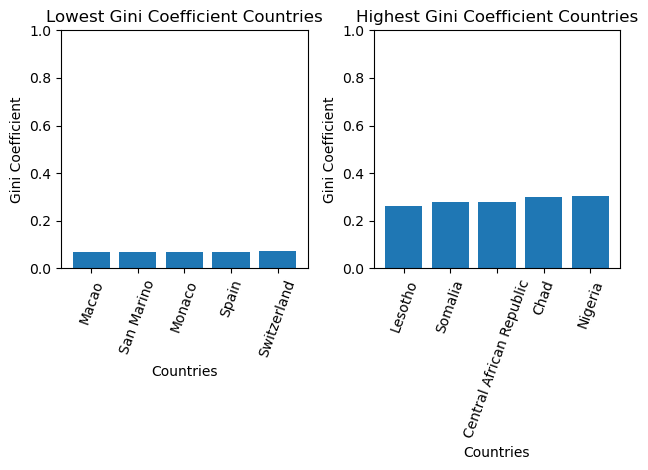

In [ ]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, sharex = False, sharey = False) # This creates the sub-plots where the first plot will show the top 5 countries with the lowest gini coefficients and the second plot will show the top 5 countries with the highest gini coefficient.

ax[0].bar(df1.head().Entity, df1.head()['Gini coefficient of lifespan inequality - Sex: female']) # This creates the first bar graph.
ax[0].set_title("Lowest Gini Coefficient Countries")
ax[0].set_xlabel("Countries")
ax[0].set_ylabel("Gini Coefficient")
ax[0].tick_params(axis = 'x', rotation = 70)
ax[0].set_ylim(0,1) # The y-limit is set from 0 to 1 because the gini coefficient is measured between 0 to 1 where 0 indicates perfect equality and 1 indicates perfect inequality.

ax[1].bar(df1.tail().Entity, df1.tail()['Gini coefficient of lifespan inequality - Sex: female']) # This creates the second bar graph.
ax[1].set_title("Highest Gini Coefficient Countries")
ax[1].set_xlabel("Countries")
ax[1].set_ylabel("Gini Coefficient")
ax[1].tick_params(axis = 'x', rotation = 70)
ax[1].set_ylim(0,1)

plt.tight_layout()
plt.show()

In [ ]:
spending_life_expectancy.head() # This dataset will be used to create the 2nd graph.

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
53,Afghanistan,2002,57.442,54.986,87.465030,796.81660,56.225,0.109768
54,Afghanistan,2003,58.472,55.849,86.229300,842.80520,57.171,0.102312
55,Afghanistan,2004,59.073,56.519,93.926300,869.03925,57.810,0.108081
56,Afghanistan,2005,59.588,56.880,105.835266,964.40810,58.247,0.109741
57,Afghanistan,2006,60.123,56.974,118.180824,1057.09660,58.553,0.111798


In [ ]:
df2 = spending_life_expectancy[spending_life_expectancy.Year == spending_life_expectancy.Year.max()]
df2   # This sub-data frame shows the data values for the recent-most year.

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
1185,Austria,2021,84.410,79.197,7236.66200,42184.6950,81.820,0.171547
2966,Canada,2021,84.368,79.609,5930.69800,44379.5940,81.976,0.133636
3337,Chile,2021,81.486,76.348,2578.84600,22324.9600,78.876,0.115514
4376,Denmark,2021,83.299,79.573,7139.64160,49258.7500,81.436,0.144942
5117,Estonia,2021,81.755,72.816,3202.41240,30499.1560,77.409,0.105000
6155,Germany,2021,83.688,78.554,7517.25500,46159.0500,81.106,0.162855
7269,Honduras,2021,72.175,67.002,557.17334,5062.1187,69.492,0.110067
7491,Iceland,2021,84.281,81.454,5614.52440,40412.6170,82.843,0.138930
7861,Ireland,2021,83.719,80.025,7305.17800,57278.4200,81.861,0.127538
8083,Italy,2021,85.054,80.585,4397.48400,34827.1370,82.865,0.126266


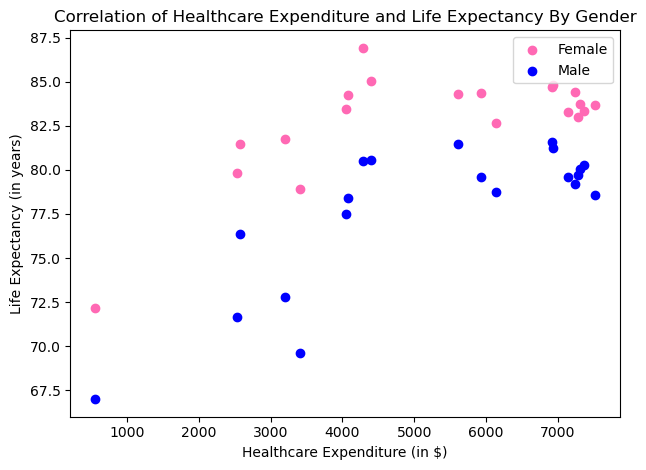

In [ ]:
plt.scatter(df2['Current health expenditure per capita, PPP (current international $)'], df2['Life expectancy - Sex: female - Age: 0 - Variant: estimates'], c = 'hotpink', label = 'Female')
plt.scatter(df2['Current health expenditure per capita, PPP (current international $)'], df2['Life expectancy - Sex: male - Age: 0 - Variant: estimates'], c = 'blue', label = 'Male')
plt.title("Correlation of Healthcare Expenditure and Life Expectancy By Gender")
plt.xlabel("Healthcare Expenditure (in $)")      # The 2nd graph is a scatter plot that shows the relationship between healthcare expenditure and the individual male and female life expectancy in the recent-most year, 2021.
plt.ylabel("Life Expectancy (in years)")             # This correlation shows that as the healthcare expenditure increases, both male and female life expectancies increase. This shows a positive correlation between the co-variables.
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
life_exp_inequality.head()  # This dataset will be used to create graph 3.

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
66,Afghanistan,AFG,2015,0.192897,62.270,33831765.0,Asia
216,Albania,ALB,2015,0.083469,78.358,2898634.0,Europe
290,Algeria,DZA,2015,0.108450,75.159,40019528.0,Africa
364,American Samoa,ASM,2015,0.098870,72.654,52895.0,Oceania
512,Andorra,AND,2015,0.076684,84.532,72194.0,Europe


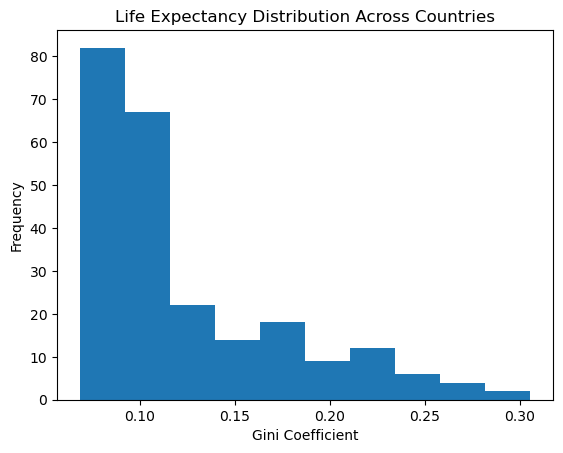

In [ ]:
plt.hist(life_exp_inequality['Gini coefficient of lifespan inequality - Sex: female'])
plt.title("Life Expectancy Distribution Across Countries")  # Since the Gini coefficient shows the level of life expectancy inequality in a country, I created a histogram to show the life expectancy distribution across the different countries in our dataset.
plt.xlabel("Gini Coefficient")           # The histogram shows that most of the countries in our dataset have a Gini coefficient closer to 0.10 indicating less life expectancy inequality.
plt.ylabel("Frequency")               # Theoretically, this means that the richer countries have higher life expectancy whereas the poorer countries have lower life expectancy.
plt.show()

In [ ]:
spending_life_expectancy.head() # This dataset will be used to create the 4th graph.

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
53,Afghanistan,2002,57.442,54.986,87.465030,796.81660,56.225,0.109768
54,Afghanistan,2003,58.472,55.849,86.229300,842.80520,57.171,0.102312
55,Afghanistan,2004,59.073,56.519,93.926300,869.03925,57.810,0.108081
56,Afghanistan,2005,59.588,56.880,105.835266,964.40810,58.247,0.109741
57,Afghanistan,2006,60.123,56.974,118.180824,1057.09660,58.553,0.111798


In [ ]:
df4 = spending_life_expectancy.sort_values('healthcare spending/gdp per capita', ascending = True)  # This sorts the "healthcare spending/gdp per capita" in ascending order.
df4 = df4[df4.Year == df4.Year.max()] # This pulls out the recent-most year (2021).
df4

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
12816,Norway,2021,84.709,81.605,6921.88230,86334.5900,83.166,0.080175
13632,Poland,2021,79.825,71.636,2528.51440,30687.6620,75.639,0.082395
5117,Estonia,2021,81.755,72.816,3202.41240,30499.1560,77.409,0.105000
15858,South Korea,2021,86.917,80.524,4289.06350,40277.9530,83.852,0.106487
7269,Honduras,2021,72.175,67.002,557.17334,5062.1187,69.492,0.110067
9778,Lithuania,2021,78.904,69.625,3411.86670,30557.0300,74.297,0.111656
3337,Chile,2021,81.486,76.348,2578.84600,22324.9600,78.876,0.115514
8083,Italy,2021,85.054,80.585,4397.48400,34827.1370,82.865,0.126266
7861,Ireland,2021,83.719,80.025,7305.17800,57278.4200,81.861,0.127538
15560,Slovenia,2021,83.425,77.525,4046.48850,31019.9430,80.434,0.130448


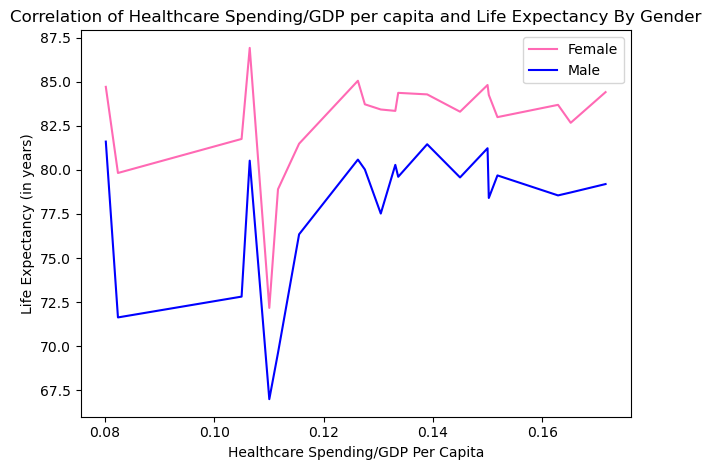

In [ ]:
plt.plot(df4['healthcare spending/gdp per capita'], df4['Life expectancy - Sex: female - Age: 0 - Variant: estimates'], c = 'hotpink', label = 'Female')
plt.plot(df4['healthcare spending/gdp per capita'], df4['Life expectancy - Sex: male - Age: 0 - Variant: estimates'], c = 'blue', label = 'Male')
plt.title("Correlation of Healthcare Spending/GDP per capita and Life Expectancy By Gender")
plt.xlabel("Healthcare Spending/GDP Per Capita")       # Graph 4 is a line plot that shows the relationship between the healthcare spending/gdp per capita and the life expectancies for both males and females.
plt.ylabel("Life Expectancy (in years)")               # Since 2021 was a peak-covid time, there was a sudden drop in both male and female life expectancies because unemployment increased and there was less spending done by people in general, including on healthcare. This dropped the life expectancies for both males and females. However, in general, there is a slight upward trend that shows that as the spending on healthcare increases, while taking the population size into account at that time, life expectancy for both males and females tended to increase.
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
spending_life_expectancy.head() # This dataset will be used to create graph 5.

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
53,Afghanistan,2002,57.442,54.986,87.465030,796.81660,56.225,0.109768
54,Afghanistan,2003,58.472,55.849,86.229300,842.80520,57.171,0.102312
55,Afghanistan,2004,59.073,56.519,93.926300,869.03925,57.810,0.108081
56,Afghanistan,2005,59.588,56.880,105.835266,964.40810,58.247,0.109741
57,Afghanistan,2006,60.123,56.974,118.180824,1057.09660,58.553,0.111798


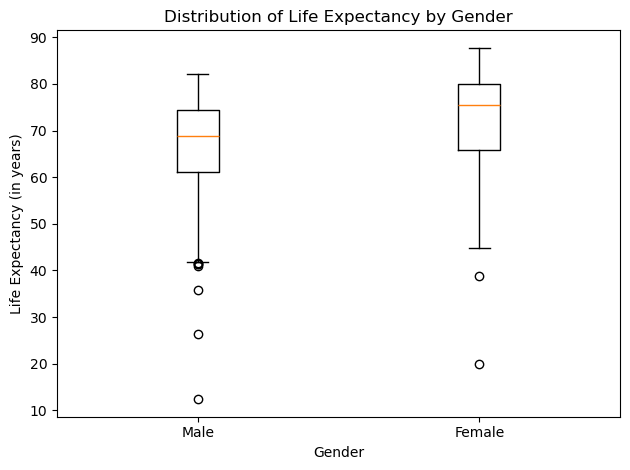

In [ ]:
male_data = spending_life_expectancy['Life expectancy - Sex: male - Age: 0 - Variant: estimates']
female_data = spending_life_expectancy['Life expectancy - Sex: female - Age: 0 - Variant: estimates']
total_data = [male_data, female_data]

plt.boxplot(x = total_data)                              # This box plot shows the 5-number summary (min, 25th percentile, median, 75th percentile, max, and outliers) of the world life expectancy over the years in the dataset.
plt.title("Distribution of Life Expectancy by Gender")   # This box plot shows that women, in general, tend to live longer than men, regardless of nationality and time.
plt.xlabel("Gender")
plt.xticks([1,2], ['Male', 'Female'])
plt.ylabel("Life Expectancy (in years)")

plt.tight_layout()
plt.show()

In [ ]:
# Pivoting.

In [ ]:
spending_life_expectancy  # This dataset will be used to create the first pivot table.

,Entity,Year,Life expectancy - Sex: female - Age: 0 - Variant: estimates,Life expectancy - Sex: male - Age: 0 - Variant: estimates,"Current health expenditure per capita, PPP (current international $)",GDP per capita,Life expectancy - Sex: all - Age: 0 - Variant: estimates,healthcare spending/gdp per capita
53,Afghanistan,2002,57.442,54.986,87.465030,796.81660,56.225,0.109768
54,Afghanistan,2003,58.472,55.849,86.229300,842.80520,57.171,0.102312
55,Afghanistan,2004,59.073,56.519,93.926300,869.03925,57.810,0.108081
56,Afghanistan,2005,59.588,56.880,105.835266,964.40810,58.247,0.109741
57,Afghanistan,2006,60.123,56.974,118.180824,1057.09660,58.553,0.111798
...,...,...,...,...,...,...,...,...
18826,Zimbabwe,2016,61.401,57.940,203.482400,1782.83010,59.760,0.114134
18827,Zimbabwe,2017,62.016,58.304,226.177220,1843.94630,60.263,0.122659
18828,Zimbabwe,2018,62.741,58.852,180.091130,1900.19920,60.906,0.094775
18829,Zimbabwe,2019,63.049,58.830,132.068700,1753.02440,61.060,0.075338


In [ ]:
spending_life_expectancy.rename(columns = {'Life expectancy - Sex: male - Age: 0 - Variant: estimates': 'Male Life Expectancy'}, inplace = True)
spending_life_expectancy.rename(columns = {'Life expectancy - Sex: female - Age: 0 - Variant: estimates': 'Female Life Expectancy'}, inplace = True)
spending_life_expectancy.rename(columns = {'Entity': 'Country'}, inplace = True)
spending_life_expectancy.rename(columns = {'Current health expenditure per capita, PPP (current international $)': 'Healthcare Expenditure'}, inplace = True)
spending_life_expectancy.rename(columns = {'Life expectancy - Sex: all - Age: 0 - Variant: estimates': 'General Life Expectancy'}, inplace = True)

spending_life_expectancy   # These codes simplify the names of the columns for an organized pivot table.

,Country,Year,Female Life Expectancy,Male Life Expectancy,Healthcare Expenditure,GDP per capita,General Life Expectancy,healthcare spending/gdp per capita
53,Afghanistan,2002,57.442,54.986,87.465030,796.81660,56.225,0.109768
54,Afghanistan,2003,58.472,55.849,86.229300,842.80520,57.171,0.102312
55,Afghanistan,2004,59.073,56.519,93.926300,869.03925,57.810,0.108081
56,Afghanistan,2005,59.588,56.880,105.835266,964.40810,58.247,0.109741
57,Afghanistan,2006,60.123,56.974,118.180824,1057.09660,58.553,0.111798
...,...,...,...,...,...,...,...,...
18826,Zimbabwe,2016,61.401,57.940,203.482400,1782.83010,59.760,0.114134
18827,Zimbabwe,2017,62.016,58.304,226.177220,1843.94630,60.263,0.122659
18828,Zimbabwe,2018,62.741,58.852,180.091130,1900.19920,60.906,0.094775
18829,Zimbabwe,2019,63.049,58.830,132.068700,1753.02440,61.060,0.075338


In [ ]:
spending_life_expectancy.set_index(['Year', 'Country'], inplace = True) # This creates the multi-index data frame.
spending_life_expectancy

,,Female Life Expectancy,Male Life Expectancy,Healthcare Expenditure,GDP per capita,General Life Expectancy,healthcare spending/gdp per capita
Year,Country,,,,,,
2002,Afghanistan,57.442,54.986,87.465030,796.81660,56.225,0.109768
2003,Afghanistan,58.472,55.849,86.229300,842.80520,57.171,0.102312
2004,Afghanistan,59.073,56.519,93.926300,869.03925,57.810,0.108081
2005,Afghanistan,59.588,56.880,105.835266,964.40810,58.247,0.109741
2006,Afghanistan,60.123,56.974,118.180824,1057.09660,58.553,0.111798
...,...,...,...,...,...,...,...
2016,Zimbabwe,61.401,57.940,203.482400,1782.83010,59.760,0.114134
2017,Zimbabwe,62.016,58.304,226.177220,1843.94630,60.263,0.122659
2018,Zimbabwe,62.741,58.852,180.091130,1900.19920,60.906,0.094775


In [ ]:
df1 = spending_life_expectancy.pivot_table(index = 'Country', columns = 'Year', values = ['Male Life Expectancy', 'Female Life Expectancy'], aggfunc = 'mean')
df1 # This pivot table shows the average life expectancy for males and females from 2000 to 2021 in each of the countries in the dataset.

Female Life Expectancy                                          \
Year                          2000    2001    2002    2003    2004    2005   
Country                                                                      
Afghanistan                    NaN     NaN  57.442  58.472  59.073  59.588   
Albania                     77.926  78.031  78.142  78.329  78.753  79.303   
Algeria                     71.944  72.295  72.842  73.027  73.642  73.962   
Angola                      49.132  50.047  50.367  52.181  53.074  54.051   
Argentina                   77.288  77.642  77.911  77.808  78.177  78.632   
...                            ...     ...     ...     ...     ...     ...   
Vietnam                     77.278  77.673  78.014  78.186  77.807  77.951   
World                       68.920     NaN     NaN     NaN     NaN     NaN   
Yemen                       64.616  65.098  65.669  66.284  66.731  67.234   
Zambia                      47.295  48.105  49.145  50.419  51.097  52.115   
Zimbabwe                       NaN     NaN     NaN     NaN     NaN     NaN   

                                             ... Male Life Expectancy          \
Year           2006    2007    2008    2009  ...                 2012    2013   
Country                                      ...                                
Afghanistan  60.123  60.804  61.428  61.791  ...               60.099  60.534   
Albania      79.943  80.584  81.076  81.282  ...               75.660  75.666   
Algeria      74.283  74.556  74.827  75.074  ...               73.493  73.680   
Angola       54.811  56.041  57.162  58.129  ...               56.677  57.404   
Argentina    78.437  77.925  78.577  78.593  ...               72.851  72.963   
...             ...     ...     ...     ...  ...                  ...     ...   
Vietnam      78.049  78.152  78.213  78.272  ...               68.979  69.042   
World           NaN     NaN     NaN     NaN  ...                  NaN     NaN   
Yemen        67.679  68.121  68.488  68.812  ...               65.553  66.028   
Zambia       53.346  54.470  55.855  56.933  ...               56.954  57.623   
Zimbabwe        NaN     NaN     NaN     NaN  ...               54.066  55.397   

                                                                          
Year           2014    2015    2016    2017    2018    2019    2020 2021  
Country                                                                   
Afghanistan  60.495  60.363  60.661  59.388  59.175  59.910  58.455  NaN  
Albania      75.830  76.281  76.662  76.997  77.448     NaN     NaN  NaN  
Algeria      73.850  73.992  74.106  74.177  74.255  74.350  71.733  NaN  
Angola       58.068  58.680  59.237  59.727  60.199  60.609  60.509  NaN  
Argentina    73.303  73.367  73.044  73.791  73.951  74.163  72.981  NaN  
...             ...     ...     ...     ...     ...     ...     ...  ...  
Vietnam      69.100  69.147  69.153  69.217  69.303  69.414  70.366  NaN  
World           NaN  69.071  69.323  69.485  69.835  70.055  69.257  NaN  
Yemen        65.996  63.985     NaN     NaN     NaN     NaN     NaN  NaN  
Zambia       58.094  58.545  58.919  59.207  59.693  60.349  60.731  NaN  
Zimbabwe     56.569  57.330  57.940  58.304  58.852  58.830  59.091  NaN  

[161 rows x 44 columns]

In [ ]:
df1.stack() # This stacks the above pivot table in a more organized format because we can see the average male and female life expectancy for each country from 2000 to 2021 with all NaN values removed.

C:\Users\Niharika\AppData\Local\Temp\ipykernel_20420\856874950.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df1.stack() # This stacks the above pivot table in a more organized format because we can see the average male and female life expectancy for each country from 2000 to 2021 with all NaN values removed.


Female Life Expectancy  Male Life Expectancy
Country     Year                                              
Afghanistan 2002                  57.442                54.986
            2003                  58.472                55.849
            2004                  59.073                56.519
            2005                  59.588                56.880
            2006                  60.123                56.974
...                                  ...                   ...
Zimbabwe    2016                  61.401                57.940
            2017                  62.016                58.304
            2018                  62.741                58.852
            2019                  63.049                58.830
            2020                  63.747                59.091

[3336 rows x 2 columns]

In [ ]:
df2 = spending_life_expectancy.pivot_table(index = 'Country', columns = 'Year', values = ['Healthcare Expenditure', 'GDP per capita'])
df2  # The 2nd pivot table shows the healthcare expenditure and GDP per capita from the years 2000 to 2021 for each country listed in the dataset.

GDP per capita                                                   \
Year                  2000        2001        2002        2003         2004   
Country                                                                       
Afghanistan            NaN         NaN    796.8166    842.8052    869.03925   
Albania          4808.4795   5285.8090   5608.9624   6004.6450   6419.87060   
Algeria          6834.5537   7218.2456   7814.8384   8590.1780   9182.29400   
Angola           2013.6362   2162.4850   2522.6719   2711.9282   3064.29860   
Argentina       14368.9420  13651.9810  12094.7720  13088.5650  14183.22600   
...                    ...         ...         ...         ...          ...   
Vietnam          2773.1016   2915.6860   3070.6934   3242.2854   3437.66430   
World            9903.8600         NaN         NaN         NaN          NaN   
Yemen            4212.1055   4249.0337   4292.0986   4326.5103   4371.39550   
Zambia           1428.5023   1504.4498   1579.0227   1698.5515   1828.30980   
Zimbabwe               NaN         NaN         NaN         NaN          NaN   

                                                                         ...  \
Year               2005        2006        2007        2008        2009  ...   
Country                                                                  ...   
Afghanistan    964.4081   1057.0966   1259.9967   1319.6074   1557.3207  ...   
Albania       6858.4673   7347.3300   7866.1577   8522.1300   8859.4720  ...   
Algeria       9969.6230  10385.7790  10974.7420  11475.0020  11907.0210  ...   
Angola        3708.7705   4592.3374   5773.5483   6743.7480   7087.6040  ...   
Argentina    15344.1570  16490.4730  17891.9430  18520.3050  17328.9770  ...   
...                 ...         ...         ...         ...         ...  ...   
Vietnam       3637.6565   3828.9077   4037.2330   4200.2354   4360.0615  ...   
World               NaN         NaN         NaN         NaN         NaN  ...   
Yemen         4485.5830   4497.2593   4516.1436   4549.0090   4593.5425  ...   
Zambia        1970.0187   2133.5940   2318.6270   2504.7570   2743.3220  ...   
Zimbabwe            NaN         NaN         NaN         NaN         NaN  ...   

            Healthcare Expenditure                                      \
Year                          2012        2013        2014        2015   
Country                                                                  
Afghanistan              155.38303   178.07903   202.26155   215.72523   
Albania                  643.14575   664.90247   726.53973   755.45200   
Algeria                  800.91000   790.96990   854.94354   842.43060   
Angola                   177.02948   208.89516   197.72545   189.54787   
Argentina               1920.12780  1960.46580  1896.80600  2050.68100   
...                            ...         ...         ...         ...   
Vietnam                  318.36240   341.31305   333.99740   346.77628   
World                          NaN         NaN         NaN  1245.42830   
Yemen                    169.29358   170.52568   164.53444   102.29128   
Zambia                   131.97697   164.48184   132.62274   148.68791   
Zimbabwe                 162.51550   179.32047   208.36397   194.87709   

                                                                              
Year               2016        2017        2018        2019        2020 2021  
Country                                                                       
Afghanistan   239.18875   264.54398   299.82254   321.52540   322.52560  NaN  
Albania       803.79640   834.28076   895.59480         NaN         NaN  NaN  
Algeria       772.11444   741.56380   741.41943   754.20950   735.75350  NaN  
Angola        190.65703   201.43640   181.07797   171.67917   184.13707  NaN  
Argentina    1824.83370  2463.52320  2216.69290  2187.82890  2089.51830  NaN  
...                 ...         ...         ...         ...         ...  ...  
Vietnam       374.03015   426.54395 

In [ ]:
df2.stack()  # This stacks the above pivot table in a more organized format because we can see the healthcare expenditure and GDP per capita for each country from 2000 to 2021 with all NaN values removed.

C:\Users\Niharika\AppData\Local\Temp\ipykernel_20420\445736038.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df2.stack()  # This stacks the above pivot table in a more organized format because we can see the healthcare expenditure and GDP per capita for each country from 2000 to 2021 with all NaN values removed.


GDP per capita  Healthcare Expenditure
Country     Year                                        
Afghanistan 2002       796.81660               87.465030
            2003       842.80520               86.229300
            2004       869.03925               93.926300
            2005       964.40810              105.835266
            2006      1057.09660              118.180824
...                          ...                     ...
Zimbabwe    2016      1782.83010              203.482400
            2017      1843.94630              226.177220
            2018      1900.19920              180.091130
            2019      1753.02440              132.068700
            2020      1585.97280              118.127060

[3336 rows x 2 columns]

In [ ]:
life_exp_inequality   # This dataset will be used to create the 3rd pivot table.

,Entity,Code,Year,Gini coefficient of lifespan inequality - Sex: female,Life expectancy - Sex: all - Age: 0 - Variant: estimates,Population - Sex: all - Age: all - Variant: estimates,Continent
66,Afghanistan,AFG,2015,0.192897,62.270,33831765.0,Asia
216,Albania,ALB,2015,0.083469,78.358,2898634.0,Europe
290,Algeria,DZA,2015,0.108450,75.159,40019528.0,Africa
364,American Samoa,ASM,2015,0.098870,72.654,52895.0,Oceania
512,Andorra,AND,2015,0.076684,84.532,72194.0,Europe
...,...,...,...,...,...,...,...
18895,Wallis and Futuna,WLF,2015,0.108654,77.450,12185.0,Oceania
18970,Western Sahara,ESH,2015,0.133665,69.275,486230.0,Africa
19119,Yemen,YEM,2015,0.158782,66.761,31159379.0,Asia
19196,Zambia,ZMB,2015,0.197461,60.728,16399090.0,Africa


In [ ]:
life_exp_inequality.rename(columns = {'Gini coefficient of lifespan inequality - Sex: female': 'Gini Coefficient'}, inplace = True)
life_exp_inequality.rename(columns = {'Entity': 'Country'}, inplace = True)
life_exp_inequality.rename(columns = {'Life expectancy - Sex: all - Age: 0 - Variant: estimates': 'General Life Expectancy'}, inplace = True)
life_exp_inequality.rename(columns = {'Population - Sex: all - Age: all - Variant: estimates': 'Population'}, inplace = True)
life_exp_inequality  # These codes simplify the column names for an organized pivot table.

,Country,Code,Year,Gini Coefficient,General Life Expectancy,Population,Continent
66,Afghanistan,AFG,2015,0.192897,62.270,33831765.0,Asia
216,Albania,ALB,2015,0.083469,78.358,2898634.0,Europe
290,Algeria,DZA,2015,0.108450,75.159,40019528.0,Africa
364,American Samoa,ASM,2015,0.098870,72.654,52895.0,Oceania
512,Andorra,AND,2015,0.076684,84.532,72194.0,Europe
...,...,...,...,...,...,...,...
18895,Wallis and Futuna,WLF,2015,0.108654,77.450,12185.0,Oceania
18970,Western Sahara,ESH,2015,0.133665,69.275,486230.0,Africa
19119,Yemen,YEM,2015,0.158782,66.761,31159379.0,Asia
19196,Zambia,ZMB,2015,0.197461,60.728,16399090.0,Africa


In [ ]:
life_exp_inequality.set_index(['Country', 'Continent'], inplace = True)
life_exp_inequality    # This creates a multi-index dataframe.

,,Code,Year,Gini Coefficient,General Life Expectancy,Population
Country,Continent,,,,,
Afghanistan,Asia,AFG,2015,0.192897,62.270,33831765.0
Albania,Europe,ALB,2015,0.083469,78.358,2898634.0
Algeria,Africa,DZA,2015,0.108450,75.159,40019528.0
American Samoa,Oceania,ASM,2015,0.098870,72.654,52895.0
Andorra,Europe,AND,2015,0.076684,84.532,72194.0
...,...,...,...,...,...,...
Wallis and Futuna,Oceania,WLF,2015,0.108654,77.450,12185.0
Western Sahara,Africa,ESH,2015,0.133665,69.275,486230.0
Yemen,Asia,YEM,2015,0.158782,66.761,31159379.0


In [ ]:
df3 = life_exp_inequality.pivot_table(index = 'Continent', columns = 'Country', values = ['Gini Coefficient', 'General Life Expectancy'])
df3   # This pivot table shows the Gini coefficient and General Life Expectancy for all the countries as columns and continents as the index.

General Life Expectancy                                         \
Country                   Afghanistan Albania Algeria American Samoa Andorra   
Continent                                                                      
Africa                            NaN     NaN  75.159            NaN     NaN   
Asia                            62.27     NaN     NaN            NaN     NaN   
Europe                            NaN  78.358     NaN            NaN  84.532   
North America                     NaN     NaN     NaN            NaN     NaN   
Oceania                           NaN     NaN     NaN         72.654     NaN   
South America                     NaN     NaN     NaN            NaN     NaN   

                                                                      ...  \
Country        Angola Anguilla Antigua and Barbuda Argentina Armenia  ...   
Continent                                                             ...   
Africa         61.042      NaN                 NaN       NaN     NaN  ...   
Asia              NaN      NaN                 NaN       NaN  74.229  ...   
Europe            NaN      NaN                 NaN       NaN     NaN  ...   
North America     NaN   77.741              76.892       NaN     NaN  ...   
Oceania           NaN      NaN                 NaN       NaN     NaN  ...   
South America     NaN      NaN                 NaN      76.6     NaN  ...   

              Gini Coefficient                                           \
Country                Uruguay Uzbekistan   Vanuatu Venezuela   Vietnam   
Continent                                                                 
Africa                     NaN        NaN       NaN       NaN       NaN   
Asia                       NaN   0.111182       NaN       NaN  0.108666   
Europe                     NaN        NaN       NaN       NaN       NaN   
North America              NaN        NaN       NaN       NaN       NaN   
Oceania                    NaN        NaN  0.130925       NaN       NaN   
South America          0.10353        NaN       NaN  0.104659       NaN   

                                                                              
Country       Wallis and Futuna Western Sahara     Yemen    Zambia  Zimbabwe  
Continent                                                                     
Africa                      NaN       0.133665       NaN  0.197461  0.215609  
Asia                        NaN            NaN  0.158782       NaN       NaN  
Europe                      NaN            NaN       NaN       NaN       NaN  
North America               NaN            NaN       NaN       NaN       NaN  
Oceania                0.108654            NaN       NaN       NaN       NaN  
South America               NaN            NaN       NaN       NaN       NaN  

[6 rows x 472 columns]

In [ ]:
df3.stack()   # This stacks the above pivot table in a more organized format because we can see the gini coefficients and general life expectancies for all the countries, grouped by their continents.

C:\Users\Niharika\AppData\Local\Temp\ipykernel_20420\195094867.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df3.stack()   # This stacks the above pivot table in a more organized format because we can see the gini coefficients and general life expectancies for all the countries, grouped by their continents.


General Life Expectancy  Gini Coefficient
Continent     Country                                                
Africa        Algeria                        75.159          0.108450
              Angola                         61.042          0.211194
              Benin                          59.123          0.237901
              Botswana                       63.215          0.178921
              Burkina Faso                   58.778          0.230016
...                                             ...               ...
South America Paraguay                       73.454          0.123706
              Peru                           75.732          0.103351
              Suriname                       70.567          0.130916
              Uruguay                        77.285          0.103530
              Venezuela                      73.004          0.104659

[236 rows x 2 columns]